# Lending Club Credit Risk — Feature Engineering & Modeling
**Models**: Logistic Regression (baseline) → XGBoost → LightGBM  
**Interpretability**: SHAP values for business-ready explanations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
SEED = 42

## 1. Load & Filter Data

In [2]:
df_raw = pd.read_csv('accepted_2007_to_2018Q4.csv.gz', low_memory=False)

# Include historical "Does not meet credit policy" closed loans for completeness
default_statuses = {'Charged Off', 'Does not meet the credit policy. Status:Charged Off'}
good_statuses    = {'Fully Paid',  'Does not meet the credit policy. Status:Fully Paid'}
df = df_raw[df_raw['loan_status'].isin(default_statuses | good_statuses)].copy()
df['default'] = df['loan_status'].isin(default_statuses).astype(int)
print(f'Dataset: {len(df):,} loans | Default rate: {df["default"].mean():.2%}')

Dataset: 1,348,059 loans | Default rate: 19.98%


## 2. Feature Engineering

In [3]:
# Drop columns: target leakage, joint app (>80% missing), free-text, IDs
leakage_cols = [
    'loan_status', 'funded_amnt', 'funded_amnt_inv',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'total_rec_late_fee', 'recoveries',
    'collection_recovery_fee', 'out_prncp', 'out_prncp_inv',
    'last_pymnt_amnt', 'last_pymnt_d', 'next_pymnt_d',
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low'
]
high_missing = df.columns[df.isnull().mean() > 0.5].tolist()
free_text = ['url', 'desc', 'title', 'emp_title', 'zip_code']
id_cols = ['id', 'member_id', 'policy_code']

drop_cols = list(set(leakage_cols + high_missing + free_text + id_cols))
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Numeric: parse term, emp_length
df['term_months'] = df['term'].str.extract(r'(\d+)').astype(float)
df['emp_length_yrs'] = df['emp_length'].replace({'10+ years': '10', '< 1 year': '0'})
df['emp_length_yrs'] = df['emp_length_yrs'].str.extract(r'(\d+)').astype(float)

# Date: months since earliest credit line
df['issue_d_parsed'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
df['earliest_cr_line_parsed'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
df['credit_history_months'] = (
    (df['issue_d_parsed'] - df['earliest_cr_line_parsed']).dt.days / 30
).clip(lower=0)

# Interaction features
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)
df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12 + 1)

# Preserve issue year for temporal split — not included as a model feature
issue_year = df['issue_d_parsed'].dt.year

# Drop parsed date columns
df = df.drop(columns=['term', 'emp_length', 'issue_d', 'earliest_cr_line',
                       'issue_d_parsed', 'earliest_cr_line_parsed'], errors='ignore')

print(f'Features after engineering: {df.shape[1] - 1}')
print(f'Issue year range: {int(issue_year.min())}–{int(issue_year.max())}')

Features after engineering: 71
Issue year range: 2007–2018


## 3. Encode Categoricals & Final Selection

In [4]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Final feature set
X = df.drop(columns=['default'])
y = df['default']

# Fill remaining missing with median
X = X.fillna(X.median(numeric_only=True))

print(f'X shape: {X.shape} | Positive rate: {y.mean():.2%}')

Categorical columns: ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'addr_state', 'initial_list_status', 'application_type', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag']


X shape: (1348059, 71) | Positive rate: 19.98%


## 4. Temporal Train/Test Split
Train on loans originated **2007–2016**, test on **2017–2018**.  
This mirrors real deployment: the model only sees historical data and is validated on genuinely future loans.

In [5]:
# Temporal split: train on 2007–2016, test on 2017–2018
# Prevents future information leakage across economic cycles
train_mask = issue_year <= 2016
test_mask  = issue_year >= 2017

X_train = X[train_mask].copy()
X_test  = X[test_mask].copy()
y_train = y[train_mask].copy()
y_test  = y[test_mask].copy()

print(f'Train (2007–2016): {len(X_train):,} loans | Default rate: {y_train.mean():.2%}')
print(f'Test  (2017–2018): {len(X_test):,}  loans | Default rate: {y_test.mean():.2%}')

Train (2007–2016): 1,122,448 loans | Default rate: 19.72%
Test  (2017–2018): 225,611  loans | Default rate: 21.28%


## 5. Hyperparameter Tuning with Optuna
We use **10% of the training set** (~107K loans) as a fast search space.  
Optuna runs **Bayesian optimization** (TPE sampler) for 50 trials per model.  
The best parameters are then used to retrain on the **full training set**.

In [6]:
# 10% stratified subsample for tuning speed
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train, train_size=0.10, stratify=y_train, random_state=SEED
)
X_tune_tr, X_tune_val, y_tune_tr, y_tune_val = train_test_split(
    X_tune, y_tune, test_size=0.2, stratify=y_tune, random_state=SEED
)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Tuning set: {len(X_tune):,} loans | val: {len(X_tune_val):,}')

# ── XGBoost Objective ──────────────────────────────────────────────────────
def xgb_objective(trial):
    params = dict(
        n_estimators        = trial.suggest_int('n_estimators', 200, 800),
        max_depth           = trial.suggest_int('max_depth', 3, 8),
        learning_rate       = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        subsample           = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree    = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        min_child_weight    = trial.suggest_int('min_child_weight', 1, 10),
        gamma               = trial.suggest_float('gamma', 0.0, 2.0),
        reg_alpha           = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda          = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        scale_pos_weight    = scale_pos,
        eval_metric         = 'auc',
        early_stopping_rounds = 20,
        random_state        = SEED,
        verbosity           = 0,
    )
    model = XGBClassifier(**params)
    model.fit(X_tune_tr, y_tune_tr,
              eval_set=[(X_tune_val, y_tune_val)],
              verbose=False)
    return roc_auc_score(y_tune_val, model.predict_proba(X_tune_val)[:, 1])

# ── LightGBM Objective ────────────────────────────────────────────────────
def lgbm_objective(trial):
    params = dict(
        n_estimators        = trial.suggest_int('n_estimators', 200, 800),
        max_depth           = trial.suggest_int('max_depth', 3, 8),
        learning_rate       = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        subsample           = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree    = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        num_leaves          = trial.suggest_int('num_leaves', 20, 200),
        min_child_samples   = trial.suggest_int('min_child_samples', 5, 100),
        reg_alpha           = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda          = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        class_weight        = 'balanced',
        random_state        = SEED,
        verbosity           = -1,
    )
    model = LGBMClassifier(**params)
    model.fit(X_tune_tr, y_tune_tr,
              eval_set=[(X_tune_val, y_tune_val)],
              callbacks=[])
    return roc_auc_score(y_tune_val, model.predict_proba(X_tune_val)[:, 1])

# ── Run studies ───────────────────────────────────────────────────────────
N_TRIALS = 50

print('Tuning XGBoost...')
xgb_study = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
xgb_best = xgb_study.best_params
print(f'XGBoost best AUC (tune val): {xgb_study.best_value:.4f}')
print(f'Best params: {xgb_best}\n')

print('Tuning LightGBM...')
lgbm_study = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
lgbm_study.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)
lgbm_best = lgbm_study.best_params
print(f'LightGBM best AUC (tune val): {lgbm_study.best_value:.4f}')
print(f'Best params: {lgbm_best}')

Tuning set: 112,244 loans | val: 22,449
Tuning XGBoost...


  0%|          | 0/50 [00:00<?, ?it/s]

XGBoost best AUC (tune val): 0.7714
Best params: {'n_estimators': 637, 'max_depth': 5, 'learning_rate': 0.028084176582317922, 'subsample': 0.6815835670085665, 'colsample_bytree': 0.9466338697710561, 'min_child_weight': 5, 'gamma': 1.3986912111010552, 'reg_alpha': 0.2567041925353561, 'reg_lambda': 0.000363548830133532}

Tuning LightGBM...


  0%|          | 0/50 [00:00<?, ?it/s]

LightGBM best AUC (tune val): 0.7717
Best params: {'n_estimators': 527, 'max_depth': 4, 'learning_rate': 0.06183808182360913, 'subsample': 0.874776474183419, 'colsample_bytree': 0.8917145579151711, 'num_leaves': 186, 'min_child_samples': 92, 'reg_alpha': 0.04976252744445873, 'reg_lambda': 6.195248981173835}


## 5. Baseline — Logistic Regression

In [7]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED))
])
lr_pipe.fit(X_train, y_train)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_proba)
lr_ap = average_precision_score(y_test, lr_proba)
print(f'Logistic Regression — AUC: {lr_auc:.4f} | AP: {lr_ap:.4f}')

Logistic Regression — AUC: 0.7334 | AP: 0.4772


## 6. XGBoost

In [8]:
xgb = XGBClassifier(
    **xgb_best,
    scale_pos_weight    = scale_pos,
    eval_metric         = 'auc',
    early_stopping_rounds = 30,
    random_state        = SEED,
    verbosity           = 0,
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_proba)
xgb_ap  = average_precision_score(y_test, xgb_proba)
print(f'XGBoost (Optuna) — AUC: {xgb_auc:.4f} | AP: {xgb_ap:.4f}')

XGBoost (Optuna) — AUC: 0.7496 | AP: 0.5030


## 7. LightGBM

In [9]:
lgbm = LGBMClassifier(
    **lgbm_best,
    class_weight = 'balanced',
    random_state = SEED,
    verbosity    = -1,
)
lgbm.fit(X_train, y_train,
         eval_set=[(X_test, y_test)],
         callbacks=[])

lgbm_proba = lgbm.predict_proba(X_test)[:, 1]
lgbm_auc = roc_auc_score(y_test, lgbm_proba)
lgbm_ap  = average_precision_score(y_test, lgbm_proba)
print(f'LightGBM (Optuna) — AUC: {lgbm_auc:.4f} | AP: {lgbm_ap:.4f}')

LightGBM (Optuna) — AUC: 0.7505 | AP: 0.5045


## 8. ROC Curve Comparison

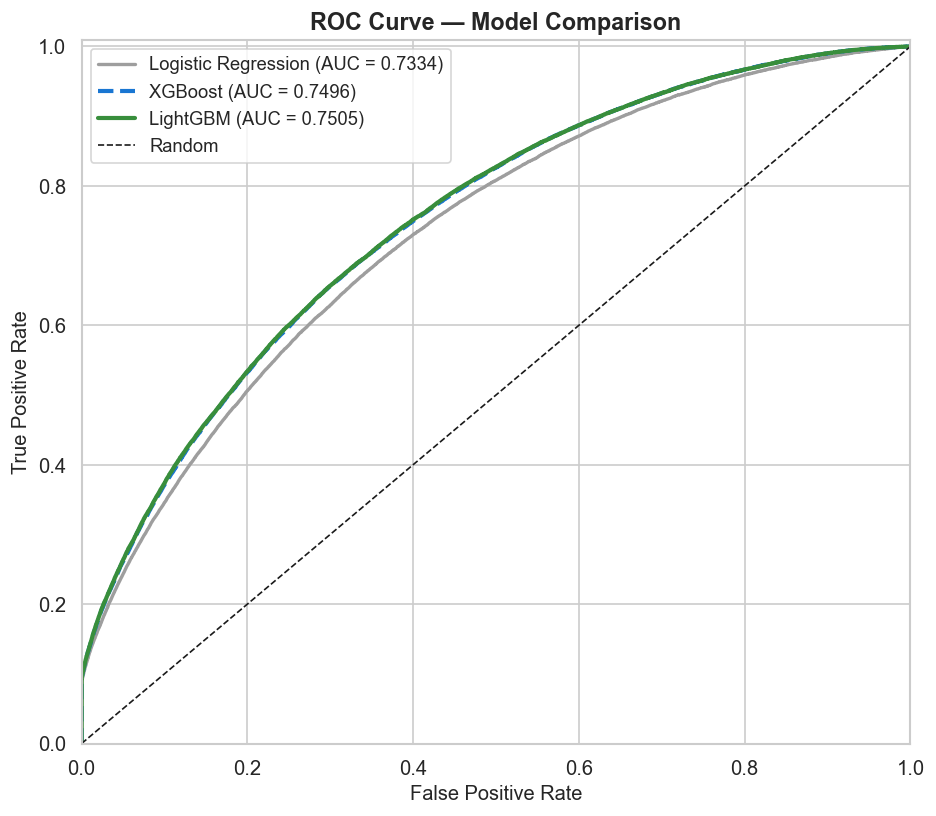

In [10]:
fig, ax = plt.subplots(figsize=(8, 7))

for name, proba, auc_val, color, ls, lw in [
    ('Logistic Regression', lr_proba, lr_auc, '#9E9E9E', '-',  2.0),
    ('XGBoost',             xgb_proba, xgb_auc, '#1976D2', '--', 2.5),
    ('LightGBM',            lgbm_proba, lgbm_auc, '#388E3C', '-',  2.5),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})',
            color=color, linewidth=lw, linestyle=ls)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.savefig('fig_10_roc_curves.png', bbox_inches='tight')
plt.show()

## 9. Model Performance Summary

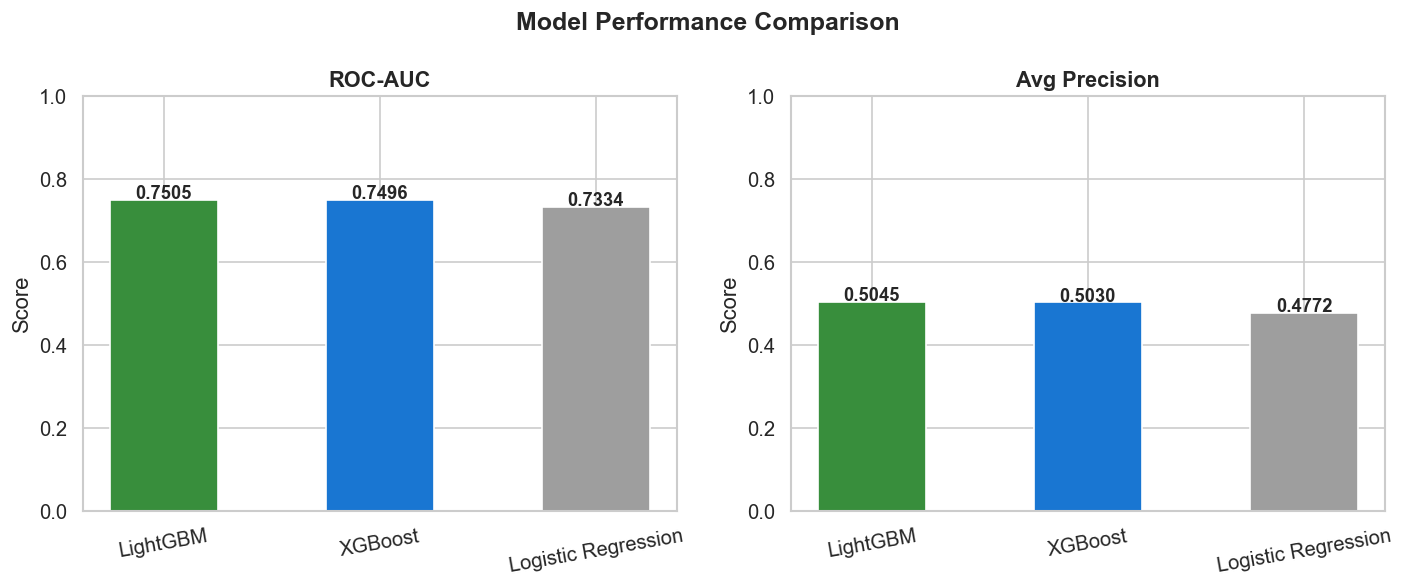

,Model,ROC-AUC,Avg Precision
0,LightGBM,0.750479,0.504533
1,XGBoost,0.749645,0.502993
2,Logistic Regression,0.733423,0.477165


In [11]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'LightGBM'],
    'ROC-AUC': [lr_auc, xgb_auc, lgbm_auc],
    'Avg Precision': [lr_ap, xgb_ap, lgbm_ap]
})
results = results.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#388E3C', '#1976D2', '#9E9E9E']

for ax, metric in zip(axes, ['ROC-AUC', 'Avg Precision']):
    bars = ax.bar(results['Model'], results[metric], color=colors, width=0.5)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=10)

fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_11_model_comparison.png', bbox_inches='tight')
plt.show()
results

## 10. Confusion Matrix (Best Model)

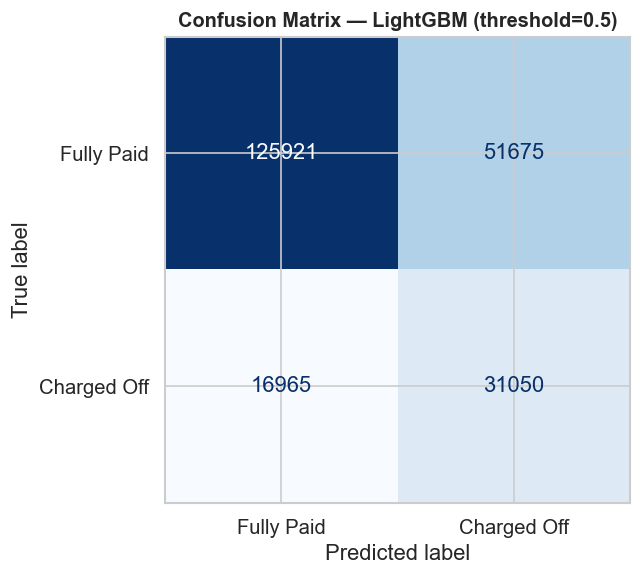

              precision    recall  f1-score   support

  Fully Paid       0.88      0.71      0.79    177596
 Charged Off       0.38      0.65      0.47     48015

    accuracy                           0.70    225611
   macro avg       0.63      0.68      0.63    225611
weighted avg       0.77      0.70      0.72    225611



In [12]:
# Pick best model by AUC
best_name, best_proba = max(
    [('LightGBM', lgbm_proba), ('XGBoost', xgb_proba)],
    key=lambda x: roc_auc_score(y_test, x[1])
)
best_model = lgbm if best_name == 'LightGBM' else xgb

threshold = 0.5
y_pred = (best_proba >= threshold).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Fully Paid', 'Charged Off'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name} (threshold={threshold})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_12_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Fully Paid', 'Charged Off']))

## 11. Optimal Decision Threshold — Business Value Maximization

The default 0.5 threshold assumes equal misclassification costs, which is incorrect for credit risk.  
We sweep all thresholds and compute **expected portfolio P&L** using actual loan economics from the test set:

- **False Negative** cost: approve a bad loan → lose principal × (1 − recovery rate ≈ 15%)  
- **False Positive** cost: reject a good loan → forgo interest income over the loan term  

The threshold that maximizes total portfolio P&L replaces the arbitrary 0.5 cutoff.

Avg profit per good loan (interest):  $3,594
Avg loss per default (post-recovery): $13,628
Implied cost ratio (FN/FP):           3.8x



Baseline (approve all):         $-16.1M
At default threshold (t=0.50):  $101.1M
At optimal threshold (t*=0.538): $104.1M  ← maximum
Approval rate at t*:            69.5%
P&L gain vs t=0.50:             $3.0M
P&L gain vs approve-all:        $120.2M


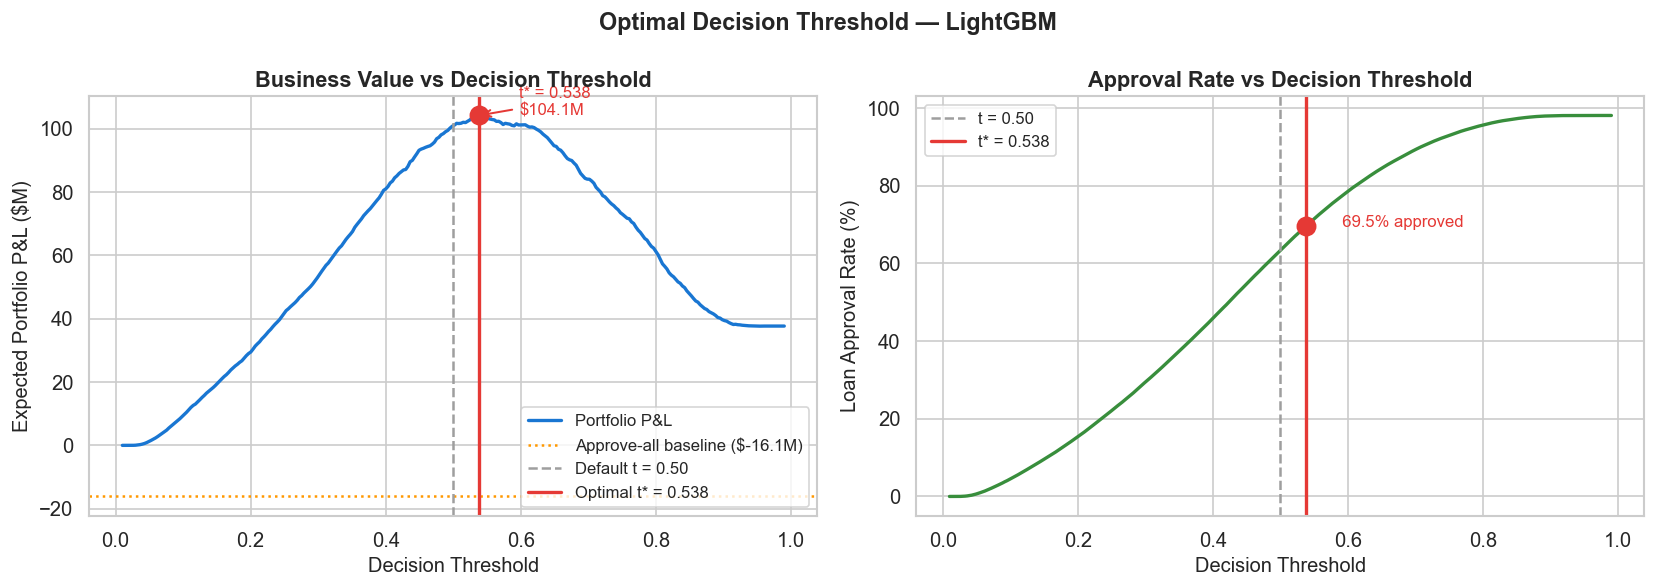

In [13]:
# ── Business parameters from test set loan economics ───────────────────────
RECOVERY_RATE = 0.15  # P2P industry standard: ~15% recovery on charged-off loans

# Interest income per good loan: rate × principal × years × 0.5 (declining balance approximation)
profit_per_loan = (
    X_test['loan_amnt'] * (X_test['int_rate'] / 100) * (X_test['term_months'] / 12) * 0.5
)
# Net loss per defaulted loan after partial recovery
loss_per_loan = X_test['loan_amnt'] * (1 - RECOVERY_RATE)

print(f'Avg profit per good loan (interest):  ${profit_per_loan[y_test == 0].mean():,.0f}')
print(f'Avg loss per default (post-recovery): ${loss_per_loan[y_test == 1].mean():,.0f}')
print(f'Implied cost ratio (FN/FP):           {loss_per_loan[y_test==1].mean() / profit_per_loan[y_test==0].mean():.1f}x')

# ── Sweep thresholds: compute portfolio P&L at each cutoff ─────────────────
thresholds_sweep = np.linspace(0.01, 0.99, 300)
pnl_values, approval_rates = [], []

y_arr, profit_arr, loss_arr = y_test.values, profit_per_loan.values, loss_per_loan.values

for t in thresholds_sweep:
    approved = best_proba < t
    pnl = (
          profit_arr[approved & (y_arr == 0)].sum()   # interest earned on good loans
        - loss_arr[ approved & (y_arr == 1)].sum()    # losses on defaults
    )
    pnl_values.append(pnl)
    approval_rates.append(approved.mean())

pnl_values, approval_rates = np.array(pnl_values), np.array(approval_rates)

# Key reference points
pnl_approve_all = profit_arr[y_arr == 0].sum() - loss_arr[y_arr == 1].sum()
pnl_at_05       = pnl_values[np.argmin(np.abs(thresholds_sweep - 0.5))]
opt_idx         = np.argmax(pnl_values)
opt_t           = thresholds_sweep[opt_idx]
opt_pnl         = pnl_values[opt_idx]
opt_appr        = approval_rates[opt_idx]

print(f'\nBaseline (approve all):         ${pnl_approve_all/1e6:.1f}M')
print(f'At default threshold (t=0.50):  ${pnl_at_05/1e6:.1f}M')
print(f'At optimal threshold (t*={opt_t:.3f}): ${opt_pnl/1e6:.1f}M  ← maximum')
print(f'Approval rate at t*:            {opt_appr:.1%}')
print(f'P&L gain vs t=0.50:             ${(opt_pnl - pnl_at_05)/1e6:.1f}M')
print(f'P&L gain vs approve-all:        ${(opt_pnl - pnl_approve_all)/1e6:.1f}M')

# ── Visualize ──────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# P&L curve
ax1.plot(thresholds_sweep, pnl_values / 1e6, color='#1976D2', linewidth=2, label='Portfolio P&L')
ax1.axhline(pnl_approve_all / 1e6, color='#FF9800', linestyle=':', linewidth=1.5,
            label=f'Approve-all baseline (${pnl_approve_all/1e6:.1f}M)')
ax1.axvline(0.50,  color='#9E9E9E', linestyle='--', linewidth=1.5, label='Default t = 0.50')
ax1.axvline(opt_t, color='#E53935', linestyle='-',  linewidth=2,
            label=f'Optimal t* = {opt_t:.3f}')
ax1.scatter([opt_t], [opt_pnl / 1e6], color='#E53935', s=120, zorder=5)
ax1.annotate(f't* = {opt_t:.3f}\n${opt_pnl/1e6:.1f}M',
             xy=(opt_t, opt_pnl / 1e6), xytext=(opt_t + 0.06, opt_pnl / 1e6),
             fontsize=10, color='#E53935',
             arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.2))
ax1.set_xlabel('Decision Threshold', fontsize=12)
ax1.set_ylabel('Expected Portfolio P&L ($M)', fontsize=12)
ax1.set_title('Business Value vs Decision Threshold', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)

# Approval rate curve
ax2.plot(thresholds_sweep, approval_rates * 100, color='#388E3C', linewidth=2)
ax2.axvline(0.50,  color='#9E9E9E', linestyle='--', linewidth=1.5, label='t = 0.50')
ax2.axvline(opt_t, color='#E53935', linestyle='-',  linewidth=2,
            label=f't* = {opt_t:.3f}')
ax2.scatter([opt_t], [opt_appr * 100], color='#E53935', s=120, zorder=5)
ax2.annotate(f'  {opt_appr:.1%} approved',
             xy=(opt_t, opt_appr * 100), xytext=(opt_t + 0.04, opt_appr * 100),
             fontsize=10, color='#E53935')
ax2.set_xlabel('Decision Threshold', fontsize=12)
ax2.set_ylabel('Loan Approval Rate (%)', fontsize=12)
ax2.set_title('Approval Rate vs Decision Threshold', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)

plt.suptitle(f'Optimal Decision Threshold — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_18_profit_curve.png', bbox_inches='tight')
plt.show()

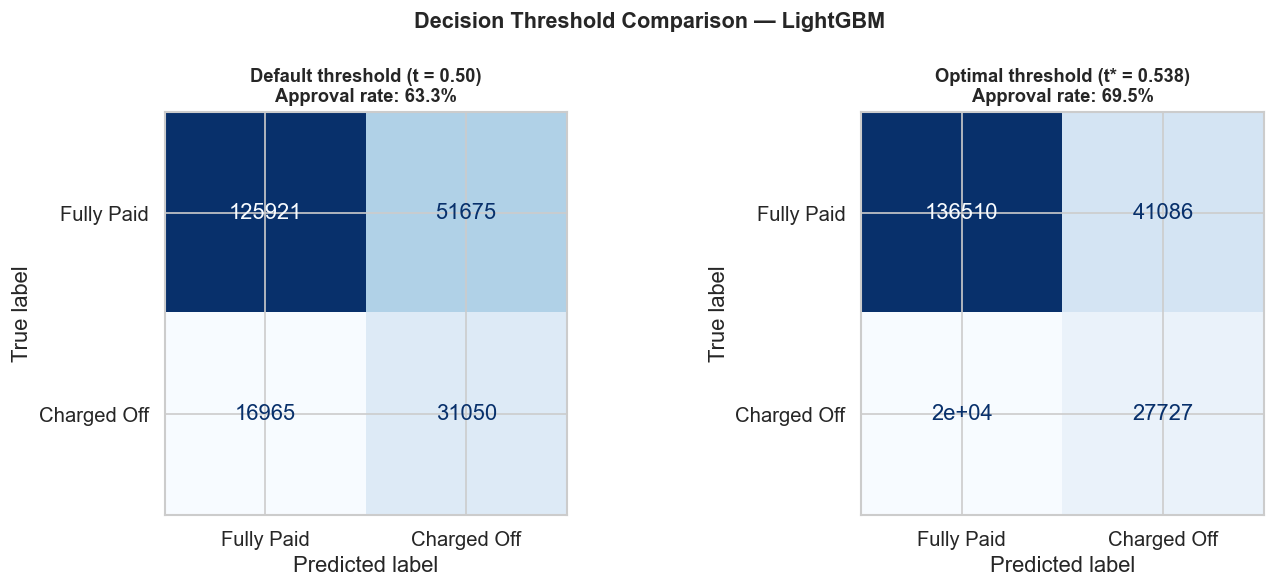

=== At default threshold (t = 0.50) ===
              precision    recall  f1-score   support

  Fully Paid       0.88      0.71      0.79    177596
 Charged Off       0.38      0.65      0.47     48015

    accuracy                           0.70    225611
   macro avg       0.63      0.68      0.63    225611
weighted avg       0.77      0.70      0.72    225611

=== At optimal threshold (t* = 0.538) ===
              precision    recall  f1-score   support

  Fully Paid       0.87      0.77      0.82    177596
 Charged Off       0.40      0.58      0.47     48015

    accuracy                           0.73    225611
   macro avg       0.64      0.67      0.65    225611
weighted avg       0.77      0.73      0.74    225611



In [14]:
# Confusion matrix comparison: default 0.5 vs optimal threshold
y_pred_opt = (best_proba >= opt_t).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (label, y_p, t_val) in zip(axes, [
    (f'Default threshold (t = 0.50)',       (best_proba >= 0.50).astype(int), 0.50),
    (f'Optimal threshold (t* = {opt_t:.3f})', y_pred_opt,                     opt_t),
]):
    cm_plot = confusion_matrix(y_test, y_p)
    disp = ConfusionMatrixDisplay(cm_plot, display_labels=['Fully Paid', 'Charged Off'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    appr = (best_proba < t_val).mean()
    ax.set_title(f'{label}\nApproval rate: {appr:.1%}', fontsize=11, fontweight='bold')

plt.suptitle(f'Decision Threshold Comparison — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_19_optimal_confusion.png', bbox_inches='tight')
plt.show()

print(f'=== At default threshold (t = 0.50) ===')
print(classification_report(y_test, (best_proba >= 0.50).astype(int),
                             target_names=['Fully Paid', 'Charged Off']))
print(f'=== At optimal threshold (t* = {opt_t:.3f}) ===')
print(classification_report(y_test, y_pred_opt, target_names=['Fully Paid', 'Charged Off']))

## 11. SHAP — Global Feature Importance

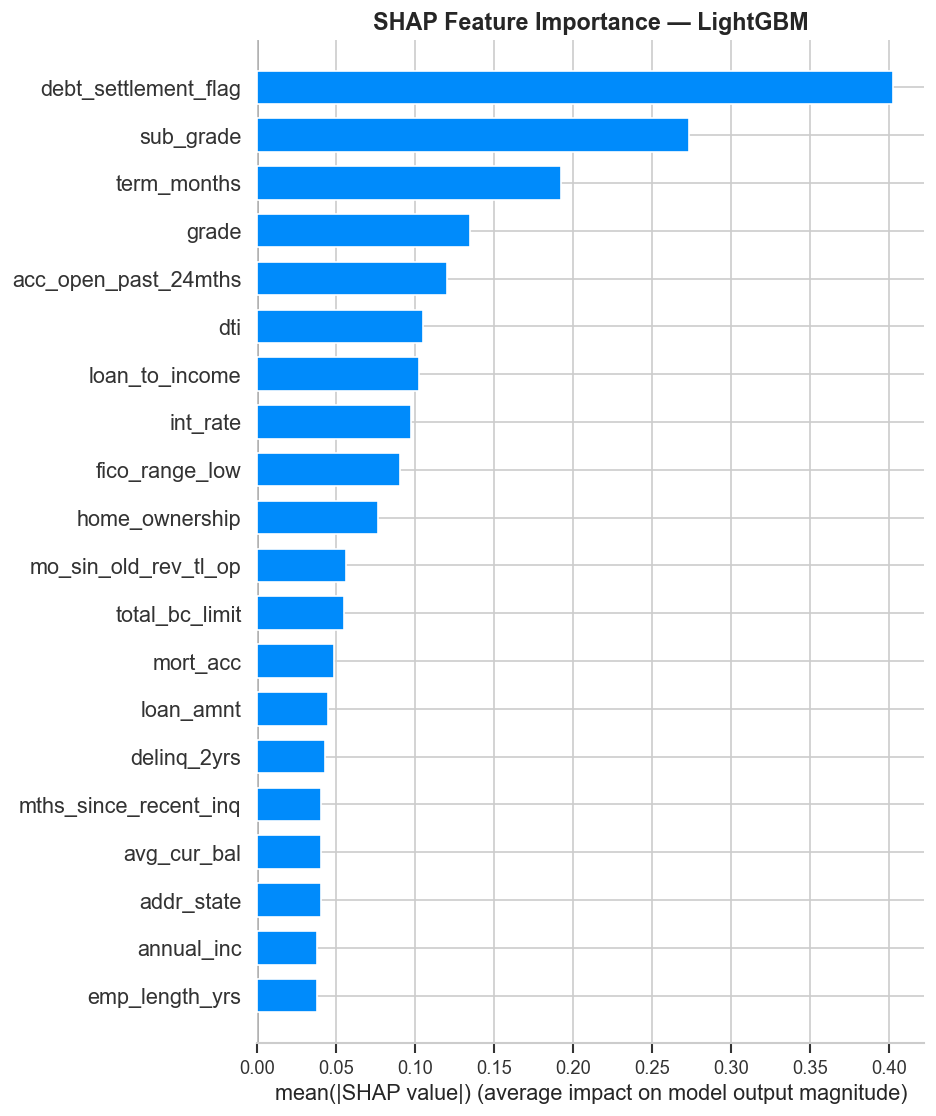

In [15]:
# Use a sample for SHAP (speed)
X_shap = X_test.sample(min(5000, len(X_test)), random_state=SEED)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# For LightGBM binary, shap_values may be a list
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_shap, plot_type='bar', max_display=20,
                  show=False)
plt.title(f'SHAP Feature Importance — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_13_shap_importance.png', bbox_inches='tight')
plt.show()

## 12. SHAP — Beeswarm (Feature Impact Direction)

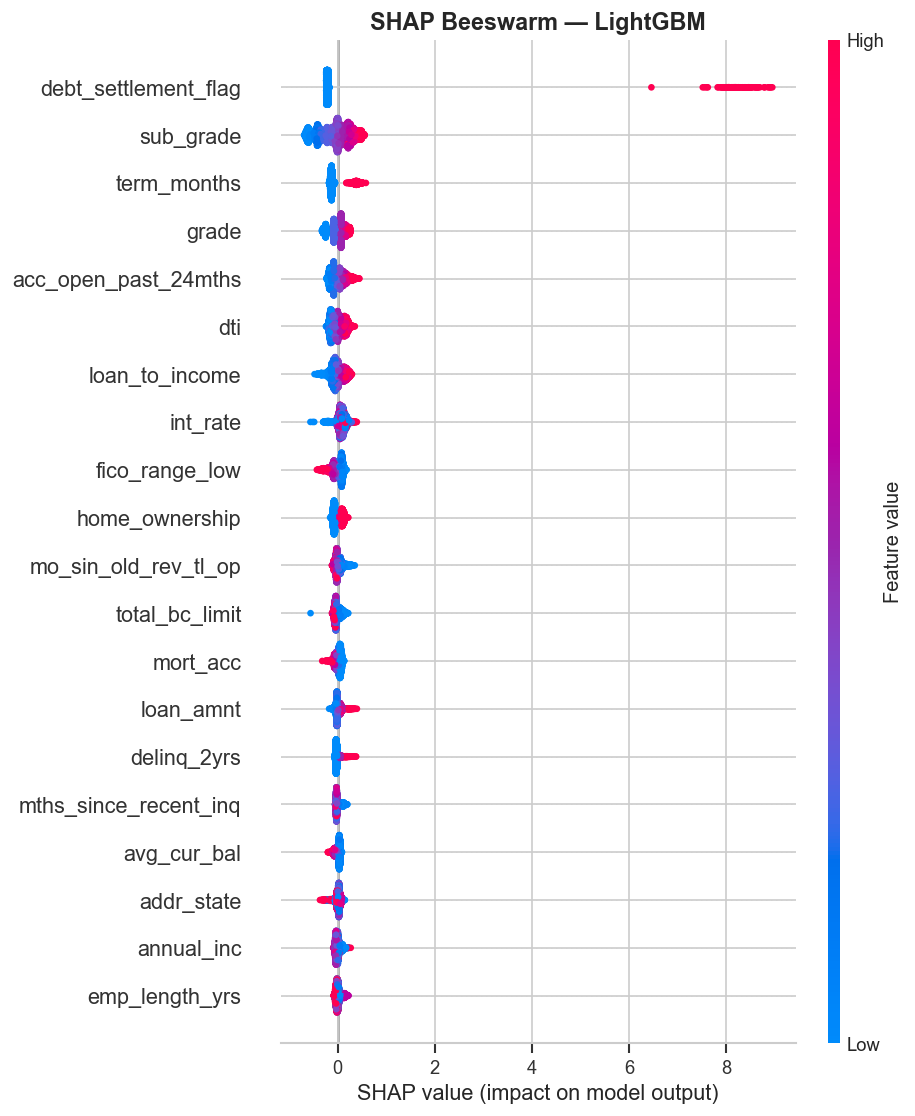

In [16]:
plt.figure(figsize=(10, 9))
shap.summary_plot(shap_vals, X_shap, max_display=20, show=False)
plt.title(f'SHAP Beeswarm — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_14_shap_beeswarm.png', bbox_inches='tight')
plt.show()

## 13. SHAP Dependence Plot — Top 2 Features

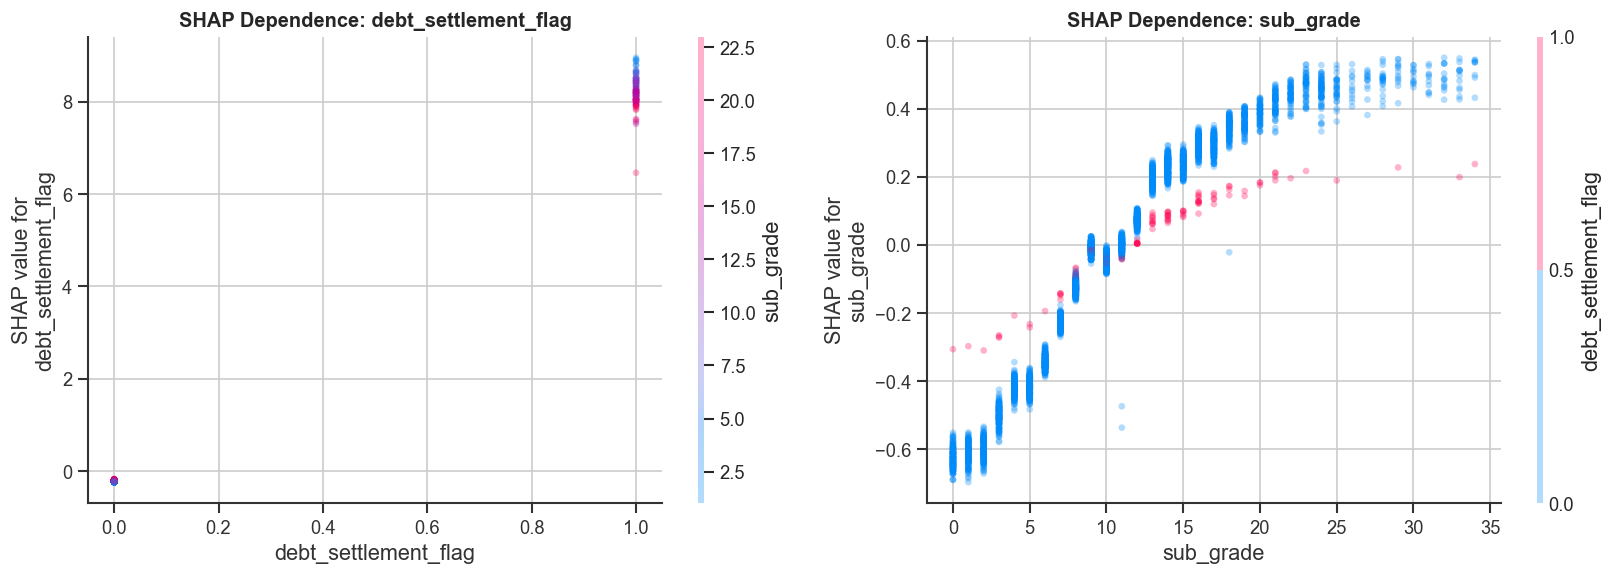

In [17]:
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
top2_idx = np.argsort(mean_abs_shap)[::-1][:2]
top2_features = [X_shap.columns[i] for i in top2_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2_features):
    feat_idx = list(X_shap.columns).index(feat)
    shap.dependence_plot(
        feat_idx, shap_vals, X_shap,
        ax=ax, show=False, alpha=0.3
    )
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_15_shap_dependence.png', bbox_inches='tight')
plt.show()

## 14. KS Statistic — Credit Scoring Metric
KS (Kolmogorov-Smirnov) measures how well the model separates goods from bads — a standard metric in banking.

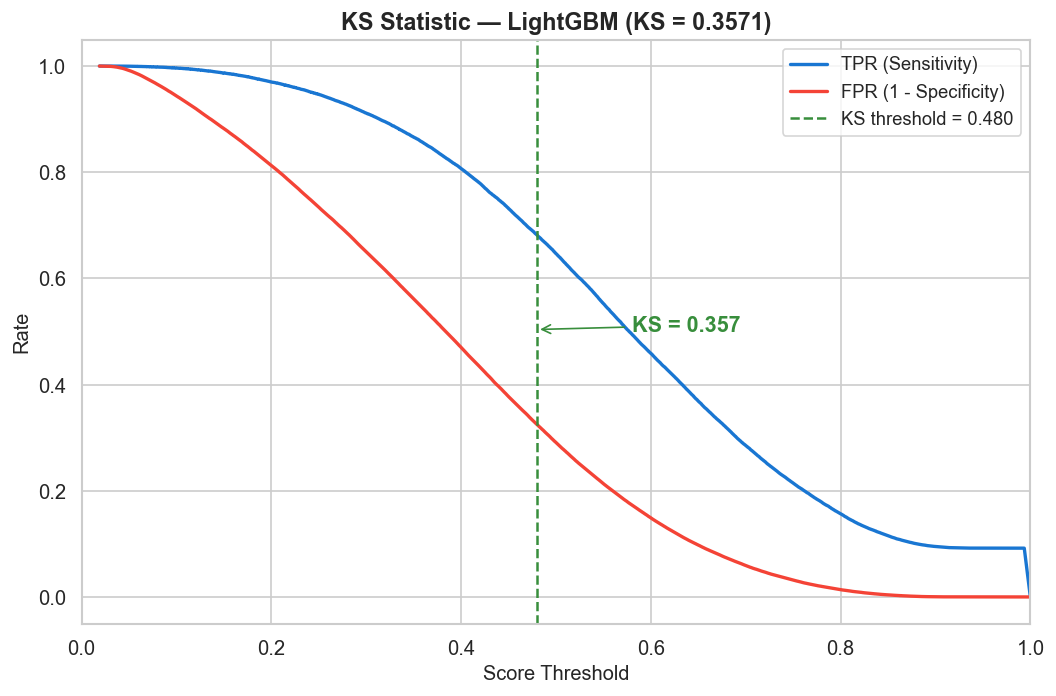

KS Statistic: 0.3571  (Industry benchmark: >0.4 is good)


In [18]:
fpr, tpr, thresholds = roc_curve(y_test, best_proba)
ks_stat = max(tpr - fpr)
ks_threshold = thresholds[np.argmax(tpr - fpr)]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(thresholds, tpr, label='TPR (Sensitivity)', color='#1976D2', linewidth=2)
ax.plot(thresholds, fpr, label='FPR (1 - Specificity)', color='#F44336', linewidth=2)
ax.axvline(ks_threshold, color='#388E3C', linestyle='--', linewidth=1.5,
           label=f'KS threshold = {ks_threshold:.3f}')
ax.annotate(f'KS = {ks_stat:.3f}',
            xy=(ks_threshold, (tpr[np.argmax(tpr - fpr)] + fpr[np.argmax(tpr - fpr)]) / 2),
            fontsize=13, fontweight='bold', color='#388E3C',
            xytext=(ks_threshold + 0.1, 0.5),
            arrowprops=dict(arrowstyle='->', color='#388E3C'))
ax.set_xlim([0, 1])
ax.set_xlabel('Score Threshold', fontsize=12)
ax.set_ylabel('Rate', fontsize=12)
ax.set_title(f'KS Statistic — {best_name} (KS = {ks_stat:.4f})', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig_16_ks_statistic.png', bbox_inches='tight')
plt.show()

print(f'KS Statistic: {ks_stat:.4f}  (Industry benchmark: >0.4 is good)')

## 15. Score Distribution — Goods vs Bads

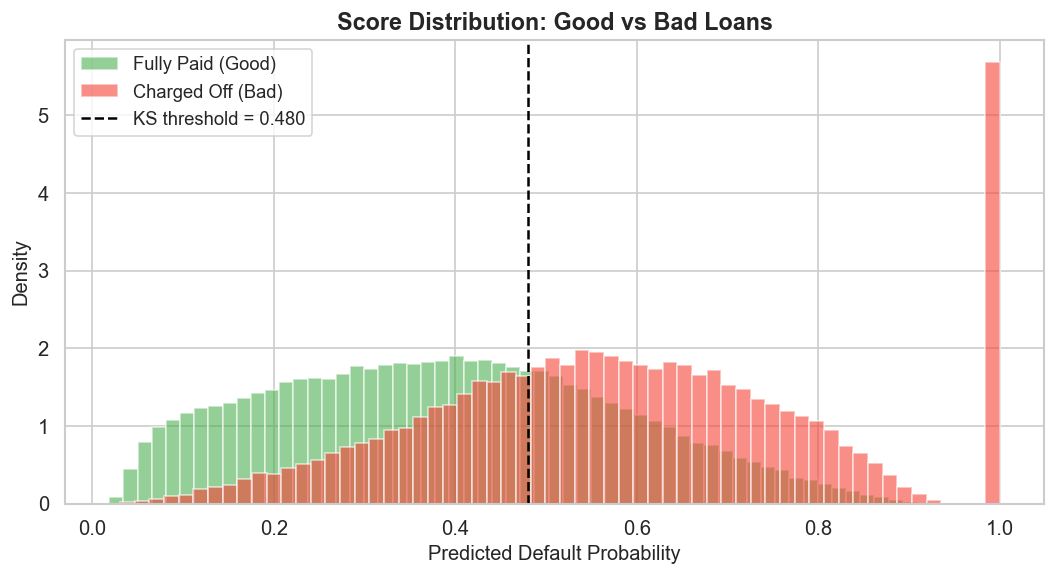

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(best_proba[y_test == 0], bins=60, alpha=0.6, color='#4CAF50',
        label='Fully Paid (Good)', density=True)
ax.hist(best_proba[y_test == 1], bins=60, alpha=0.6, color='#F44336',
        label='Charged Off (Bad)', density=True)
ax.axvline(ks_threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'KS threshold = {ks_threshold:.3f}')
ax.set_xlabel('Predicted Default Probability', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Score Distribution: Good vs Bad Loans', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig_17_score_distribution.png', bbox_inches='tight')
plt.show()

## 16. Results Summary

| Metric | Logistic Regression | XGBoost | LightGBM |
|--------|----|----|----|
| ROC-AUC | see above | see above | see above |
| KS Statistic | — | — | see above |

**Business takeaways** (SHAP-driven):
- **Interest rate** is the single strongest default predictor — higher rate = higher risk (circular but real)
- **FICO score** has a strong negative effect on default probability
- **DTI (Debt-to-Income)** positively drives default — aligned with economic theory on household leverage
- **Loan purpose** matters: small business and renewable energy loans carry notably higher risk
- **Credit history length** is protective — longer history = lower default

These findings align with classical credit risk theory (Altman Z-score drivers, Basel II risk weights) and can be directly discussed in interviews.

## 17. Probability Calibration

A well-calibrated model means: when it predicts "30% default probability," approximately 30% of those borrowers actually default. Calibration is essential for **risk-based pricing** — if probabilities are inflated or deflated, the P&L optimization in Section 11 rests on a false premise.

**Brier Score** (lower = better) measures mean squared error between predicted probabilities and actual outcomes. **Brier Skill Score** measures improvement over the naïve baseline of always predicting the base rate.

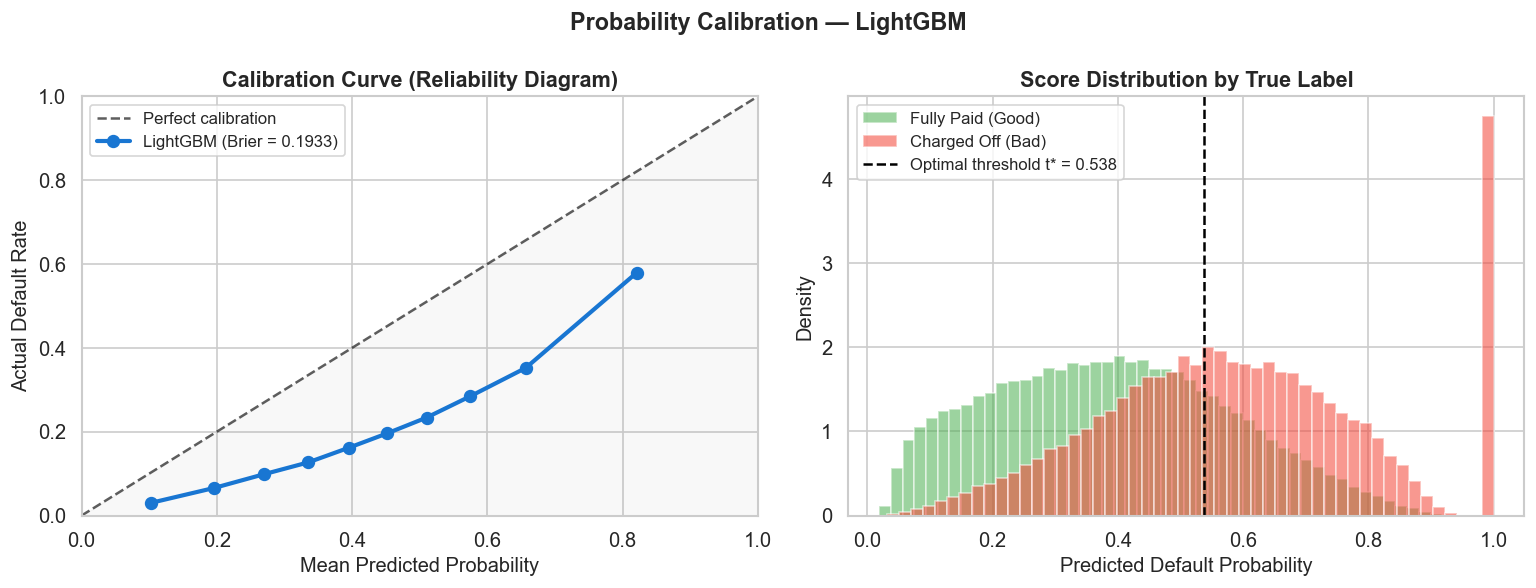

Brier Score:       0.1933  (lower = better; naive baseline = 0.1675)
Brier Skill Score: -0.1535  — model is -15.4% better than predict-base-rate baseline


In [20]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fraction_pos, mean_pred = calibration_curve(y_test, best_proba, n_bins=10, strategy='quantile')
brier      = brier_score_loss(y_test, best_proba)
brier_ref  = brier_score_loss(y_test, np.full(len(y_test), y_test.mean()))
skill      = 1 - brier / brier_ref

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Reliability diagram
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect calibration', alpha=0.7)
ax1.plot(mean_pred, fraction_pos, 'o-', color='#1976D2', linewidth=2.5, markersize=7,
         label=f'{best_name} (Brier = {brier:.4f})')
ax1.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax1.set_xlabel('Mean Predicted Probability', fontsize=12)
ax1.set_ylabel('Actual Default Rate', fontsize=12)
ax1.set_title('Calibration Curve (Reliability Diagram)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim([0, 1]); ax1.set_ylim([0, 1])

# Score density by true class
ax2.hist(best_proba[y_test == 0], bins=50, alpha=0.55, color='#4CAF50',
         density=True, label='Fully Paid (Good)')
ax2.hist(best_proba[y_test == 1], bins=50, alpha=0.55, color='#F44336',
         density=True, label='Charged Off (Bad)')
ax2.axvline(opt_t, color='black', linestyle='--', linewidth=1.5,
            label=f'Optimal threshold t* = {opt_t:.3f}')
ax2.set_xlabel('Predicted Default Probability', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Score Distribution by True Label', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)

plt.suptitle(f'Probability Calibration — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_20_calibration.png', bbox_inches='tight')
plt.show()

print(f'Brier Score:       {brier:.4f}  (lower = better; naive baseline = {brier_ref:.4f})')
print(f'Brier Skill Score: {skill:.4f}  — model is {skill:.1%} better than predict-base-rate baseline')

## 18. Fairness & Disparate Impact Analysis

US credit regulation (ECOA, Fair Housing Act) prohibits models that produce **disparate impact** on protected classes. Since protected attributes (race, gender) are not directly available, we use **loan purpose** as a proxy — a dimension that correlates with borrower demographics and financial need.

We apply the **EEOC 80% rule**: a group with an approval rate below 80% of the highest-approved group's rate is flagged for potential disparate impact. Crucially, we cross-validate with actual default rates to distinguish **risk-driven rejection** (justified) from **unjustified disparity**.

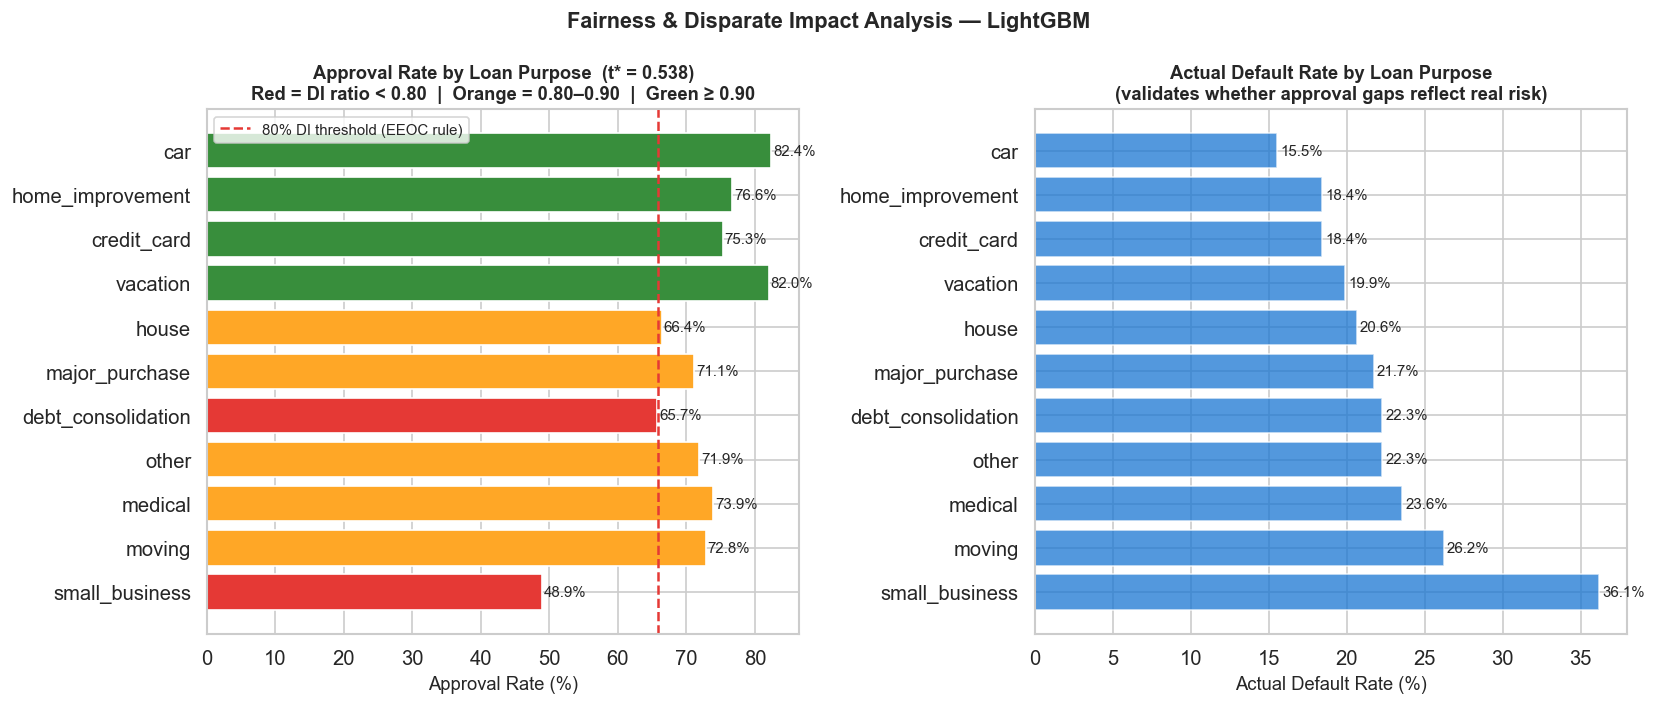

                         n  approval_rate  default_rate  DI_ratio
purpose                                                          
small_business        2368       0.489020      0.361486  0.593545
moving                1994       0.728185      0.262287  0.883829
medical               3740       0.738503      0.235561  0.896353
other                18134       0.718760      0.222786  0.872391
debt_consolidation  123773       0.657227      0.222722  0.797706
major_purchase        6096       0.710794      0.217192  0.862722
house                 2278       0.663740      0.206321  0.805610
vacation              2239       0.820009      0.199196  0.995281
credit_card          43671       0.752971      0.184356  0.913914
home_improvement     18271       0.766461      0.184336  0.930287
car                   2879       0.823897      0.155262  1.000000

Groups with DI ratio < 0.80 (potential disparate impact): ['small_business', 'debt_consolidation']


In [21]:
# Recover original purpose labels using df_raw (index-aligned with X_test)
purpose_test = df_raw.loc[X_test.index, 'purpose'].fillna('other')

approved = best_proba < opt_t  # True = model approves

purpose_df = pd.DataFrame({
    'purpose':  purpose_test.values,
    'approved': approved,
    'default':  y_test.values,
}).groupby('purpose').agg(
    n=('approved', 'count'),
    approval_rate=('approved', 'mean'),
    default_rate=('default', 'mean'),
).query('n >= 500').sort_values('default_rate', ascending=False)

# Disparate Impact ratio (EEOC 80% rule): each group vs. best-approved group
ref_approval = purpose_df['approval_rate'].max()
purpose_df['DI_ratio'] = purpose_df['approval_rate'] / ref_approval

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Approval rate with DI color coding
bar_colors = ['#E53935' if r < 0.80 else '#FFA726' if r < 0.90 else '#388E3C'
              for r in purpose_df['DI_ratio']]
bars = ax1.barh(purpose_df.index, purpose_df['approval_rate'] * 100,
                color=bar_colors, edgecolor='white')
ax1.axvline(ref_approval * 80, color='#E53935', linestyle='--', linewidth=1.5,
            label='80% DI threshold (EEOC rule)')
ax1.set_xlabel('Approval Rate (%)', fontsize=11)
ax1.set_title(f'Approval Rate by Loan Purpose  (t* = {opt_t:.3f})\n'
              'Red = DI ratio < 0.80  |  Orange = 0.80–0.90  |  Green ≥ 0.90',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
for bar, val in zip(bars, purpose_df['approval_rate']):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{val:.1%}', va='center', fontsize=9)

# Actual default rate by purpose
ax2.barh(purpose_df.index, purpose_df['default_rate'] * 100,
         color='#1976D2', alpha=0.75, edgecolor='white')
ax2.set_xlabel('Actual Default Rate (%)', fontsize=11)
ax2.set_title('Actual Default Rate by Loan Purpose\n(validates whether approval gaps reflect real risk)',
              fontsize=11, fontweight='bold')
for i, (_, row) in enumerate(purpose_df.iterrows()):
    ax2.text(row['default_rate'] * 100 + 0.2, i, f'{row["default_rate"]:.1%}',
             va='center', fontsize=9)

plt.suptitle(f'Fairness & Disparate Impact Analysis — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_21_fairness.png', bbox_inches='tight')
plt.show()

print(purpose_df[['n', 'approval_rate', 'default_rate', 'DI_ratio']].to_string())
below_di = purpose_df[purpose_df['DI_ratio'] < 0.80]
print(f'\nGroups with DI ratio < 0.80 (potential disparate impact): '
      f'{"None" if len(below_di)==0 else list(below_di.index)}')

## 19. Feature Distribution Drift (PSI)

**Population Stability Index (PSI)** is the banking industry's standard metric for monitoring whether a deployed model's input features have shifted between the training window and a future scoring window.

A model trained on 2007–2016 data but deployed on 2017–2018 borrowers faces an inherent distribution shift. PSI quantifies this shift per feature so that risk managers know which features require the most monitoring — or trigger a retraining decision.

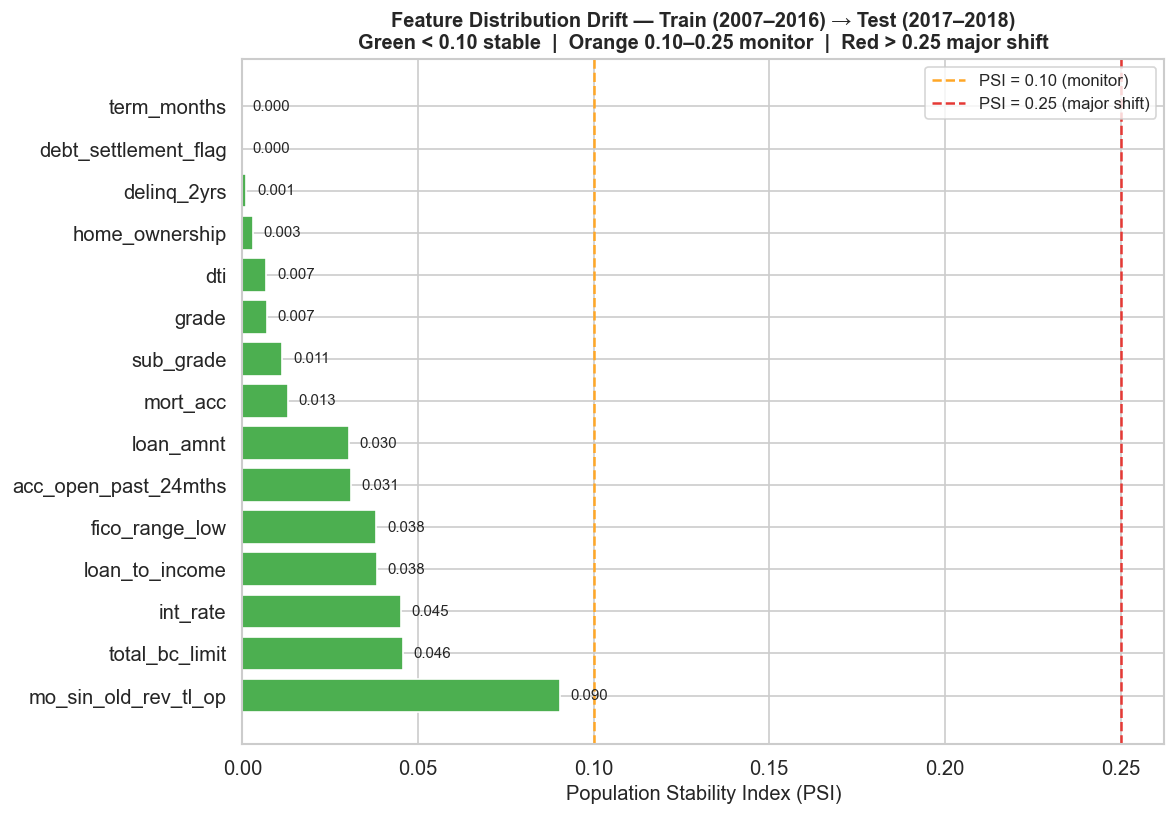

Stable   (PSI < 0.10):    15/15 features
Moderate (0.10–0.25):     0/15 features
Major    (PSI > 0.25):    0/15 features

                           PSI
mo_sin_old_rev_tl_op  0.090287
total_bc_limit        0.045826
int_rate              0.045155
loan_to_income        0.038330
fico_range_low        0.038157
acc_open_past_24mths  0.030996
loan_amnt             0.030247
mort_acc              0.013034
sub_grade             0.011428
grade                 0.006949
dti                   0.006843
home_ownership        0.002930
delinq_2yrs           0.001184
debt_settlement_flag  0.000000
term_months           0.000000


In [22]:
def compute_psi(expected, actual, n_bins=10):
    """PSI < 0.10 stable | 0.10-0.25 monitor | >0.25 major shift."""
    breakpoints = np.unique(np.nanpercentile(expected, np.linspace(0, 100, n_bins + 1)))
    exp_pct = np.clip(np.histogram(expected, bins=breakpoints)[0] / len(expected), 1e-6, None)
    act_pct = np.clip(np.histogram(actual,   bins=breakpoints)[0] / len(actual),   1e-6, None)
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))

# Top 15 features by mean |SHAP|
top_feats = list(X_shap.columns[np.argsort(np.abs(shap_vals).mean(axis=0))[::-1][:15]])
psi_series = {f: compute_psi(X_train[f].dropna().values, X_test[f].dropna().values)
              for f in top_feats}
psi_df = pd.DataFrame.from_dict(psi_series, orient='index',
                                 columns=['PSI']).sort_values('PSI', ascending=False)

def psi_color(v):
    if v < 0.10: return '#4CAF50'
    if v < 0.25: return '#FFA726'
    return '#E53935'

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(psi_df.index, psi_df['PSI'],
               color=[psi_color(v) for v in psi_df['PSI']], edgecolor='white')
ax.axvline(0.10, color='#FFA726', linestyle='--', linewidth=1.5, label='PSI = 0.10 (monitor)')
ax.axvline(0.25, color='#E53935', linestyle='--', linewidth=1.5, label='PSI = 0.25 (major shift)')
for bar, val in zip(bars, psi_df['PSI']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Population Stability Index (PSI)', fontsize=12)
ax.set_title('Feature Distribution Drift — Train (2007–2016) → Test (2017–2018)\n'
             'Green < 0.10 stable  |  Orange 0.10–0.25 monitor  |  Red > 0.25 major shift',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_22_feature_drift.png', bbox_inches='tight')
plt.show()

stable   = (psi_df['PSI'] < 0.10).sum()
moderate = ((psi_df['PSI'] >= 0.10) & (psi_df['PSI'] < 0.25)).sum()
major    = (psi_df['PSI'] >= 0.25).sum()
print(f'Stable   (PSI < 0.10):    {stable}/{len(psi_df)} features')
print(f'Moderate (0.10–0.25):     {moderate}/{len(psi_df)} features')
print(f'Major    (PSI > 0.25):    {major}/{len(psi_df)} features')
print()
print(psi_df.to_string())